In [ ]:
# Load dataset
import pandas as pd

# New, corrected line:
df = pd.read_csv('marketing_campaign.tsv', sep='\t')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [37]:
import pandas as pd

# Use tab separator
df = pd.read_csv("marketing_campaign.csv", sep='\t')

# Check columns
print(df.columns)


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


--- Contingency Table (Observed Frequencies: Education vs. Response) ---
Response      0    1
Education           
2n Cycle    181   22
Basic        52    2
Graduation  975  152
Master      313   57
PhD         385  101

             CHI-SQUARED TEST RESULTS: EDUCATION vs. RESPONSE
Chi-Square Statistic: 23.0761
P-value: 0.0001
Degrees of Freedom: 4

--- Conclusion ---
Conclusion: **Reject the Null Hypothesis** (p < 0.05).
Interpretation: There is a **statistically significant association** between a customer's **Education Level** and Campaign Acceptance.
Actionable Insight: Campaign targeting and messaging should be tailored to different education groups.

Expected Frequencies (if variables were independent):
Response         0       1
Education                 
2n Cycle    172.73   30.27
Basic        45.95    8.05
Graduation  958.96  168.04
Master      314.83   55.17
PhD         413.53   72.47


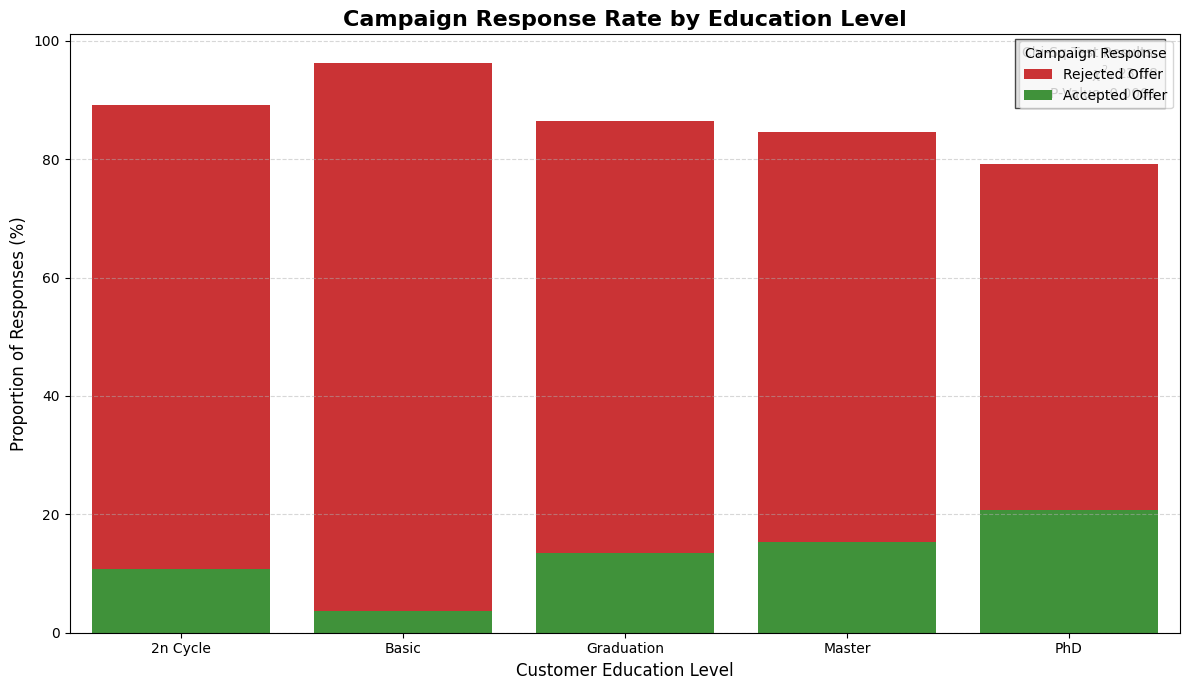

In [ ]:

import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('marketing_campaign.tsv', sep='\t')
df.columns = df.columns.str.strip().str.replace(' ', '_')

df_clean = df.dropna(subset=['Education', 'Response']).copy()
df_clean['Response'] = df_clean['Response'].astype(str)
df_clean['Response_Label'] = df_clean['Response'].map({
    '1': 'Accepted Offer',
    '0': 'Rejected Offer'
})

contingency_table = pd.crosstab(df_clean['Education'], df_clean['Response'])

chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print("--- Contingency Table (Observed Frequencies: Education vs. Response) ---")
print(contingency_table)

print("\n" + "="*60)
print("             CHI-SQUARED TEST RESULTS: EDUCATION vs. RESPONSE")
print("="*60)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

alpha = 0.05
print("\n--- Conclusion ---")
if p_value < alpha:
    print("Conclusion: **Reject the Null Hypothesis** (p < 0.05).")
    print("Interpretation: There is a **statistically significant association** between a customer's **Education Level** and Campaign Acceptance.")
    print("Actionable Insight: Campaign targeting and messaging should be tailored to different education groups.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (p > 0.05).")
    print("Interpretation: The two variables are independent (no significant association).")

expected_df = pd.DataFrame(expected_freq, index=contingency_table.index, columns=contingency_table.columns)
print("\nExpected Frequencies (if variables were independent):")
print(expected_df.round(2))
print("="*60)

response_proportions = df_clean.groupby('Education')['Response_Label'].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    x='Education', 
    y='Percent', 
    hue='Response_Label', 
    data=response_proportions,
    palette={'Accepted Offer': '#33a02c', 'Rejected Offer': '#e31a1c'},
    dodge=False
)

plt.text(
    0.98, 
    0.98, 
    f"Chi-Sq Test Results:\n$\chi^2$: {chi2:.2f}\nP-Value: {p_value:.4f}",
    transform=plt.gca().transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox={'facecolor': 'lightgray', 'alpha': 0.7, 'pad': 5}
)

plt.title(
    "Campaign Response Rate by Education Level", 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel("Customer Education Level", fontsize=12)
plt.ylabel("Proportion of Responses (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Campaign Response', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()